In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 1024, #context length
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

# TRAINING LOOP FOR THE LLM

In [2]:
import torch
import torch.nn as nn
import time
import tiktoken
from classes import GPTModel, create_dataloader_v1, calc_loss_batch, calc_loss_loader, text_to_token_ids, token_ids_to_text, generate_text_simple

print('All imports successful')

All imports successful


In [3]:
import gc

# Force garbage collection and flush CUDA cache
gc.collect()
torch.cuda.empty_cache()

# Sanity check available memory
print(f"Allocated VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Reserved VRAM:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Allocated VRAM: 0.00 GB
Reserved VRAM:  0.00 GB


In [4]:
torch.manual_seed(123)  # For reproducibility
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference
tokenizer = tiktoken.get_encoding("gpt2")

In [5]:
with open("data/harry_potter.txt", "r", encoding="utf-8") as f:
    text_data = f.read()

In [6]:
text_data[:100]  # Display the first 100 characters of the text data

"Harry Potter and the Sorcerer's Stone \n\nCHAPTER ONE \n\nTHE BOY WHO LIVED \n\nMr. and Mrs. Dursley, of n"

In [7]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print(f"Total characters: {total_characters}\nTotal tokens: {total_tokens}")

Total characters: 442744
Total tokens: 113793


In [8]:
# Training and validation split
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print("Split data into training and validation sets completed.")

Split data into training and validation sets completed.


In [9]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("Ratio of training set:", train_tokens / (train_tokens + val_tokens))
print("All tokens:", train_tokens + val_tokens)

Training tokens: 100352
Validation tokens: 11264
Ratio of training set: 0.8990825688073395
All tokens: 111616


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

## Training loop

Step 1: Initialize lists to track losses and tokens seen

Step 2: Start the main training loop

Step 3: Reset loss gradients from previous batch iteration

Step 4: Calculate loss gradients

Step 5: Update model weights using loss gradients

Step 6: Optional evaluation step

Step 7: Print a sample text after each epoch

In [11]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                        eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                        f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

The evaluate_model function calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets

In [12]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training.

In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier

In [13]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Let's see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function we defined earlier.

In [14]:
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device) 
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.558, Val loss 9.532
Ep 1 (Step 000005): Train loss 7.771, Val loss 7.734
Ep 1 (Step 000010): Train loss 6.647, Val loss 6.617
Ep 1 (Step 000015): Train loss 6.256, Val loss 6.247
Ep 1 (Step 000020): Train loss 6.074, Val loss 6.151
Ep 1 (Step 000025): Train loss 6.105, Val loss 6.040
Ep 1 (Step 000030): Train loss 5.973, Val loss 5.953
Ep 1 (Step 000035): Train loss 5.688, Val loss 5.839
Ep 1 (Step 000040): Train loss 5.573, Val loss 5.772
Ep 1 (Step 000045): Train loss 5.570, Val loss 5.664
Every effort moves you.                                                 
Ep 2 (Step 000050): Train loss 5.404, Val loss 5.604
Ep 2 (Step 000055): Train loss 5.326, Val loss 5.564
Ep 2 (Step 000060): Train loss 5.375, Val loss 5.503
Ep 2 (Step 000065): Train loss 5.280, Val loss 5.467
Ep 2 (Step 000070): Train loss 5.129, Val loss 5.382
Ep 2 (Step 000075): Train loss 4.852, Val loss 5.320
Ep 2 (Step 000080): Train loss 5.078, Val loss 5.264
Ep 2 (Step 000085): Train 

As we can see, based on the results printed during the training, the training loss improves drastically, starting with a value of 9.558 and converging to 0.552.

The language skills of the model have improved quite a lot.

Similar to the training set loss, we can see that the validation loss starts high (9.532) and decreases during the training.

However, it never becomes as small as the training set loss and remains at 6.114 after the 10th epoch.

Let's create a simple plot that shows the training and validation set losses side by side

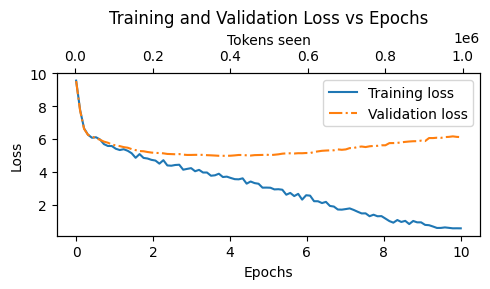

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    plt.title("Training and Validation Loss vs Epochs")

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch.

This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data.

We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, from "Harry potter" text file.

This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs.

Usually, it's common to train a model on a much, much larger dataset for only one epoch.